<a href="https://colab.research.google.com/github/FelixOtero19/Introducion_Ciencia_de_datos/blob/main/02_clase_cuaderno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción a la Ciencia de Datos · S100
## Clase 2 — Cuaderno de clase

**Prof. Gabriel Soto, M.Sc.** · UTP · `gabriel.soto@utp.ac.pa`

| | |
|---|---|
| **Parte A** · Repaso relámpago | Sintaxis, tipos y estructuras. Rápido: 20 min. |
| **Parte B** · NumPy, pandas, matplotlib | Aquí nos quedamos. |

Cada bloque grande cierra con un **🟠 EN VIVO**: una celda `# TODO` con **una sola tarea**,
que escribimos juntos, en vivo, aquí en pantalla.

> Primero lo intentamos entre todos. Nadie escribe la respuesta antes de proponerla.

In [1]:
# Las tres librerías del curso. El "as np" es un apodo: escribimos np.array, no numpy.array.
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
# que los gráficos salgan aquí abajo, dentro del cuaderno (no en una ventana aparte)
%matplotlib inline

# Paleta del curso: un solo color para los datos, salvo que el color signifique algo.
AZUL, GRIS, REJILLA = "#13294B", "#5F6472", "#D3D8E0"

# rcParams = los valores por defecto de TODOS los gráficos de aquí en adelante.
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,   # sin marco arriba/derecha
                     "axes.grid": True, "axes.axisbelow": True,              # rejilla detrás de los datos
                     "grid.color": REJILLA, "axes.titleweight": "bold", "font.size": 10})

print("Python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)

Python 3.13.15 | numpy 2.1.3 | pandas 2.2.3


---
# Parte A · Repaso relámpago
> pasamos rápido, sin ejercicios

## A1 · Las tres capas de un lenguaje

| Capa | Pregunta | Falla así |
|---|---|---|
| **Sintaxis** | ¿está bien escrito? | `print("hola"` → `SyntaxError` |
| **Semántica estática** | ¿tiene sentido? | `3 + "hola"` → `TypeError` |
| **Semántica** | ¿significa lo que yo quería? | **corre y da mal el número** |

In [2]:
# 1. Sintaxis: Python la revisa ANTES de ejecutar nada.
try: compile('print("hola"', "<clase>", "exec")
except SyntaxError as e: print("1. SyntaxError:", e.msg)

# 2. Semántica estática: bien escrito, pero no significa nada.
try: 3 + "hola"
except TypeError as e: print("2. TypeError:", e)

# 3. Semántica: corre, no se queja, y está mal. ESTE es el peligroso.
print("3. ", "3" + "4", "← esperábamos 7. Nadie nos avisó.")

1. SyntaxError: '(' was never closed
2. TypeError: unsupported operand type(s) for +: 'int' and 'str'
3.  34 ← esperábamos 7. Nadie nos avisó.


## A2 · Objetos: escalares y no escalares
> **el tipo manda**: a un número se le suma, a un texto no se le resta

| | Definición | Tipos |
|---|---|---|
| **Escalares** | Indivisibles, sin partes | `int` `float` `bool` `NoneType` |
| **No escalares** | Tienen estructura interna | `str` `list` `tuple` `dict` |

In [3]:
# ── ESCALARES: un solo valor. No tiene partes. ──────────────────────────
edad      = 21                  # int      — cantidad entera
precio    = 3.27                # float    — cantidad con decimales
es_activo = True                # bool     — sí o no
sin_dato  = None                # NoneType — "aquí no hay valor"

# ── NO ESCALARES: tienen partes adentro. ────────────────────────────────
ciudad    = "Panamá"                      # str   — partes: caracteres
notas     = [90, 85, 78]                  # list  — partes: elementos
coord     = (8.98, -79.52)                # tuple — partes: elementos (fijos)
alumno    = {"nombre": "Ana", "nota": 90} # dict  — partes: llave → valor

# type() dice de qué tipo es cada objeto. Ante un error, esta es la primera pregunta.
for x in [edad, precio, es_activo, sin_dato, ciudad, notas, coord, alumno]:
    print(f"{str(x):32} → {type(x).__name__}")

# ── La diferencia operativa: al escalar no le puedes pedir una parte. ───
print("\nciudad[0] =", ciudad[0], "| ciudad[-1] =", ciudad[-1], "| len(ciudad) =", len(ciudad))
print("notas[0]  =", notas[0], "| len(notas)  =", len(notas))
print('alumno["nota"] =', alumno["nota"], "← el dict se pide por llave, no por posición")

try: edad[0]                    # pedirle la "primera parte" a un número
except TypeError as e: print("\nedad[0]   →", e, "  ← 21 es atómico")
try: len(edad)                  # medir el largo de un número
except TypeError as e: print("len(edad) →", e, "  ← no tiene partes que contar")

# Ojo: 21 y "21" se ven casi igual y NO son lo mismo.
print('\n"21"[0] =', "21"[0], " ← el str sí tiene partes:",
      type("21").__name__, "vs", type(21).__name__)

21                               → int
3.27                             → float
True                             → bool
None                             → NoneType
Panamá                           → str
[90, 85, 78]                     → list
(8.98, -79.52)                   → tuple
{'nombre': 'Ana', 'nota': 90}    → dict

ciudad[0] = P | ciudad[-1] = á | len(ciudad) = 6
notas[0]  = 90 | len(notas)  = 3
alumno["nota"] = 90 ← el dict se pide por llave, no por posición

edad[0]   → 'int' object is not subscriptable   ← 21 es atómico
len(edad) → object of type 'int' has no len()   ← no tiene partes que contar

"21"[0] = 2  ← el str sí tiene partes: str vs int


## A3 · ¿Cuál uso: `list`, `tuple` o `dict`?

| | `list` | `tuple` | `dict` |
|---|---|---|---|
| Sintaxis | `[ ]` | `( )` | `{llave: valor}` |
| Se accede | por índice | por índice | **por llave** |
| ¿Modificable? | sí | **no** | sí |
| Cuándo | colección que crece | dato fijo que no debe cambiar | buscar por etiqueta |

In [4]:
L = [30.1, 31.4, 29.8]                  # list  — ordenada y MUTABLE (se puede cambiar)
t = (8.98, -79.52)                      # tuple — ordenada e INMUTABLE: coordenadas, fechas
d = {"ciudad": "David", "renta": 450}   # dict  — pares llave: valor

# list y tuple se acceden por POSICIÓN (empezando en 0); el dict, por LLAVE.
print("L[0] =", L[0], "| t[0] =", t[0], '| d["renta"] =', d["renta"])

# La lista sí se deja modificar...
L[0] = 99
print("\nL mutada:", L)

# ...la tupla no. Por eso se usa para datos que NO deben cambiar por accidente.
try: t[0] = 99
except TypeError as e: print("t[0] = 99 →", e)

# Y pedirle al dict una llave que no existe es un error, no un valor vacío.
try: d["renta_x"]
except KeyError as e: print("d['renta_x'] → KeyError:", e)

L[0] = 30.1 | t[0] = 8.98 | d["renta"] = 450

L mutada: [99, 31.4, 29.8]
t[0] = 99 → 'tuple' object does not support item assignment
d['renta_x'] → KeyError: 'renta_x'


## A4 · ¿Por qué unas cosas llevan punto y otras no?
> **función**: el dato va adentro · **método**: le pertenece al objeto

In [5]:
L = [3, 1, 2]

# FUNCIÓN: existe por su cuenta y el dato va ADENTRO del paréntesis.
print("len(L)   =", len(L), "  ← FUNCIÓN")

# MÉTODO: le pertenece al objeto, va después del punto y actúa sobre él.
L.sort()                       # ordena L en su lugar; no devuelve nada
print("L.sort() →", L, " ← MÉTODO: le pertenece a L")

# Cada tipo trae SUS métodos. La lista no sabe hacer .len()
try: L.len()
except AttributeError as e: print("L.len()  →", e)

# Truco: escribe  L.  y presiona Tab. Sale todo lo que la lista sabe hacer.

len(L)   = 3   ← FUNCIÓN
L.sort() → [1, 2, 3]  ← MÉTODO: le pertenece a L
L.len()  → 'list' object has no attribute 'len'


---
---
# Parte B · Las tres librerías

> **NumPy** guarda los números → **pandas** los organiza en tablas (y por dentro usa NumPy)
> → **matplotlib** los convierte en gráficos.

---
# 1 · NumPy — arreglos y vectorización

El `ndarray`: elementos **del mismo tipo**, **tamaño fijo**, y las operaciones se aplican
**a todo el arreglo a la vez**, sin `for`.

In [6]:
# Tres notas, guardadas de dos formas: lista de Python vs arreglo de NumPy.
notas_lista   = [80, 90, 70]             # list
notas_arreglo = np.array([80, 90, 70])   # ndarray — el mismo dato, otro contenedor

# Queremos DUPLICAR cada nota. Mira lo que hace cada contenedor:
print("lista   * 2 →", notas_lista * 2,   " ← repitió la lista. NO era eso.")
print("arreglo * 2 →", notas_arreglo * 2, " ← multiplicó CADA número: VECTORIZACIÓN")

# Sumarle 5 puntos a todas: con la lista hay que escribir un for; con NumPy, no.
print("\ncon for     →", [n + 5 for n in notas_lista])
print("arreglo + 5 →", notas_arreglo + 5, " ← misma idea, sin for")

# Y los resúmenes ya vienen incluidos en el arreglo:
print("\npromedio →", notas_arreglo.mean(), "| máx →", notas_arreglo.max())

lista   * 2 → [80, 90, 70, 80, 90, 70]  ← repitió la lista. NO era eso.
arreglo * 2 → [160 180 140]  ← multiplicó CADA número: VECTORIZACIÓN

con for     → [85, 95, 75]
arreglo + 5 → [85 95 75]  ← misma idea, sin for

promedio → 80.0 | máx → 90


> **Regla del curso:** si escribiste un `for` sobre datos, busca la forma vectorizada.

## 1.1 · Acceder a los elementos

In [7]:
a = np.array([10, 20, 30, 40, 50])

# Cada elemento tiene una POSICIÓN (índice), y se cuenta desde 0, no desde 1:
#   valor  :  10  20  30  40  50
#   índice :   0   1   2   3   4
print("a     =", a)
print("a[0]  =", a[0],  " ← el PRIMERO")
print("a[2]  =", a[2],  " ← el tercero (¡índice 2!)")
print("a[-1] =", a[-1], " ← el ÚLTIMO: los negativos cuentan desde el final")

# Para cambiar un valor se le asigna en su posición:
a[2] = 99
print("\na[2] = 99 →", a)

# Si te pasas del último índice, NumPy avisa (no inventa un valor):
try: a[10]
except IndexError as e: print("a[10] → IndexError:", e)

a     = [10 20 30 40 50]
a[0]  = 10  ← el PRIMERO
a[2]  = 30  ← el tercero (¡índice 2!)
a[-1] = 50  ← el ÚLTIMO: los negativos cuentan desde el final

a[2] = 99 → [10 20 99 40 50]
a[10] → IndexError: index 10 is out of bounds for axis 0 with size 5


## 1.2 · Atributos, y el eje
`ndim` ejes · `shape` tamaño de cada eje · `size` total · `dtype` tipo (**uno solo** para todo)

In [8]:
# Arreglo de 2 dimensiones: 2 filas × 4 columnas.
a = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8]])

print("ndim", a.ndim,      # 2      → cuántos ejes tiene (filas y columnas)
      "| shape", a.shape,  # (2, 4) → tamaño de cada eje
      "| size", a.size,    # 8      → cuántos números en total
      "| dtype", a.dtype)  # int64  → UN solo tipo para todo el arreglo

# En 2D se indexa [fila, columna]. Los dos puntos ":" significan "todas".
print("a[1, 3] =", a[1, 3], " ← fila 1, columna 3")
print("a[:, 2] =", a[:, 2], " ← TODAS las filas, columna 2")

# axis dice en qué dirección resumir:
print("\n.mean()       =", a.mean(),       " ← todo")
print(".mean(axis=0) =", a.mean(axis=0), " ← por columna")
print(".mean(axis=1) =", a.mean(axis=1), " ← por fila")

ndim 2 | shape (2, 4) | size 8 | dtype int64
a[1, 3] = 8  ← fila 1, columna 3
a[:, 2] = [3 7]  ← TODAS las filas, columna 2

.mean()       = 4.5  ← todo
.mean(axis=0) = [3. 4. 5. 6.]  ← por columna
.mean(axis=1) = [2.5 6.5]  ← por fila


> **Mnemotecnia del `axis`:** *el eje que pones es el eje que desaparece.*

## 1.3 · Resumir, acceder y operar sin un solo `for`

In [9]:
puntajes = np.array([80, 95, 60, 100, 45, 70, 88, 55])

# 1) Los resúmenes vienen de fábrica: un método por cada pregunta.
print("promedio", puntajes.mean(), "| mediana", np.median(puntajes), "| máx", puntajes.max())

# 2) Acceder por índice, igual que en una lista. El primero es el 0; el -1 es el último.
print("\nel primero :", puntajes[0], "| el último :", puntajes[-1])

# 3) Rebanar [desde:hasta] — el "hasta" NO se incluye.
print("los tres primeros      :", puntajes[0:3])
print("del tercero en adelante:", puntajes[2:])

# 4) Vectorización: la operación se aplica a CADA elemento, sin un solo for.
print("\nsubidos 5 puntos :", puntajes + 5)
print("en escala 0-1    :", (puntajes / 100).round(2))

promedio 74.125 | mediana 75.0 | máx 100

el primero : 80 | el último : 55
los tres primeros      : [80 95 60]
del tercero en adelante: [ 60 100  45  70  88  55]

subidos 5 puntos : [ 85 100  65 105  50  75  93  60]
en escala 0-1    : [0.8  0.95 0.6  1.   0.45 0.7  0.88 0.55]


---

### 🟠 EN VIVO — NumPy

`temps` tiene la temperatura máxima de cada día de una semana en la ciudad de Panamá.

**¿Cuál fue el promedio de la semana, cuál el día más caluroso, y cuánto es todo eso
en grados Fahrenheit?** Sin `for`.

In [35]:
# Temperatura máxima diaria, una semana en la ciudad de Panamá (°C)
temps = np.array([31.5, 32.8, 30.1, 33.4, 29.7, 34.2, 31.0])

# TODO: 1) el promedio de la semana, con .mean()
print(f"promedio de la semana fue {temps.mean():.1f}")
#       2) el día más caluroso, con .max()
print(f"el día más caluroso fue el {temps.max()}")
#       3) los siete días en °F, sin un solo for:   °F = °C * 9/5 + 32
print(f"los siete días en °F son {temps * 9/5 + 32}")

promedio de la semana fue 31.8
el día más caluroso fue el 34.2
los siete días en °F son [88.7  91.04 86.18 92.12 85.46 93.56 87.8 ]


---
---
# 2 · pandas — el DataFrame

- **`Series`** = una columna (un arreglo de NumPy **con etiquetas**)
- **`DataFrame`** = varias Series juntas; **un dtype por columna** → tabla heterogénea
- Es la rejilla de Excel, pero con miles de filas y sin tocar el mouse

In [11]:
# Una Series es UNA columna: los valores (como un arreglo de NumPy)
# más un ÍNDICE de etiquetas que le pone nombre a cada fila.
s = pd.Series([149, 225, 89], index=["Manhattan", "Brooklyn", "Queens"])
print(s, "\n")   # izquierda: el índice · derecha: los valores

# Se accede por la ETIQUETA; no hace falta saber en qué posición está.
print('s["Brooklyn"] =', s["Brooklyn"], " ← por etiqueta, como un dict")

# Y hereda todos los resúmenes de NumPy.
print("s.mean()      =", round(s.mean(), 2), " ← y se resume, como en NumPy")

Manhattan    149
Brooklyn     225
Queens        89
dtype: int64 

s["Brooklyn"] = 225  ← por etiqueta, como un dict
s.mean()      = 154.33  ← y se resume, como en NumPy


In [12]:
# Un DataFrame se arma con un dict:
#   cada LLAVE  = el nombre de una columna
#   cada VALOR  = la lista con el contenido de esa columna
df0 = pd.DataFrame({"ciudad": ["David", "Colón"],   # columna de texto
                    "renta":  [450, 600]})          # columna de números
print(df0, "\n")   # la columna 0, 1 de la izquierda es el índice: pandas lo pone solo

# .dtypes dice de qué tipo es CADA columna. Aquí está la diferencia con NumPy:
# el ndarray tiene UN dtype para todo; el DataFrame, uno POR COLUMNA.
print(df0.dtypes)

# Un corchete  → Series    (una sola columna)
# Dos corchetes → DataFrame (una LISTA de columnas, aunque pidas una sola)
print('\ntype(df0["renta"])            →', type(df0["renta"]).__name__)
print('type(df0[["ciudad","renta"]])  →', type(df0[["ciudad", "renta"]]).__name__)

  ciudad  renta
0  David    450
1  Colón    600 

ciudad    object
renta      int64
dtype: object

type(df0["renta"])            → Series
type(df0[["ciudad","renta"]])  → DataFrame


> **Un corchete o dos.** `df["renta"]` es una `Series`; `df[["renta"]]` es un `DataFrame`.
> Se imprimen casi igual y no son lo mismo.

## 2.1 · Cargar los datos: Airbnb en Nueva York

La lámina 18 usa «¿cuánto renta un inmueble?» como el ejemplo de regresión del curso.
Este es ese problema, con datos reales: **48,895 alojamientos** de Nueva York.
Hoy lo exploramos; en el Módulo 4 lo modelamos.

> 📥 Descarga [*New York City Airbnb Open Data*](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)
> y pon `AB_NYC_2019.csv` en una carpeta `datos/`. Si no está, la celda arma una tabla
> equivalente en memoria (cifras **simuladas**, no citar) y la clase sigue igual.

In [44]:
from pathlib import Path
ARCHIVO = Path("datos") / "AB_NYC_2019.csv"

# ── Plan B: si no está el CSV, generamos una tabla con la misma forma ──
# (no hay que entender esta función; solo fabrica datos parecidos para que la clase corra)
def _simular(n=3000):
    r = np.random.default_rng(2026)                  # generador con semilla fija: siempre igual
    dist = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
    base = dict(zip(dist, [5.10, 4.70, 4.45, 4.30, 4.35]))     # nivel de precio por distrito
    tipo = ["Entire home/apt", "Private room", "Shared room"]
    aj = dict(zip(tipo, [0.55, -0.10, -0.75]))                 # ajuste por tipo de habitación
    d  = r.choice(dist, n, p=[.44, .41, .12, .02, .01])
    rt = r.choice(tipo, n, p=[.52, .45, .03])
    precio = np.exp([base[x] for x in d] + np.array([aj[t] for t in rt])
                    + r.normal(0, .55, n)).round().astype(int)
    precio[r.random(n) < .0004] = 0                            # unos pocos ceros: error de captura
    precio[r.choice(n, n // 900, replace=False)] = r.integers(3000, 10001, n // 900)  # la cola cara
    nunca = r.random(n) < .206                                 # 20 % nunca reseñado → de ahí los NaN
    nrev = np.where(nunca, 0, 1 + r.negative_binomial(1.1, .07, n))
    fechas = pd.to_datetime("2019-07-08") - pd.to_timedelta(r.integers(0, 1500, n), unit="D")
    return pd.DataFrame({
        "id": np.arange(n), "neighbourhood_group": d,
        "neighbourhood": [f"{x[:3]}-Barrio {r.integers(1, 9)}" for x in d],
        "latitude": (40.73 + r.normal(0, .05, n)).round(5),
        "longitude": (-73.95 + r.normal(0, .05, n)).round(5),
        "room_type": rt, "price": precio,
        "minimum_nights": r.choice([1, 2, 3, 5, 7, 30], n, p=[.4, .25, .15, .1, .06, .04]),
        "number_of_reviews": nrev,
        "last_review": pd.Series(fechas).where(~nunca),        # NaT donde nunca hubo reseña
        "reviews_per_month": np.where(nunca, np.nan, (r.gamma(1.8, .65, n) + .01).round(2)),
        "availability_365": r.integers(0, 366, n)})

# read_csv lee el archivo y lo convierte en DataFrame.
# parse_dates convierte esa columna de texto a fecha de verdad (si no, queda como str).
if ARCHIVO.exists():
    df = pd.read_csv(ARCHIVO, parse_dates=["last_review"])
    FUENTE = "Kaggle · NYC Airbnb Open Data 2019 — datos reales"
else:
    df = _simular()
    FUENTE = "⚠️ SIMULADOS (falta datos/AB_NYC_2019.csv) — no citar estas cifras"

print(FUENTE, "|", df.shape)   # .shape = (filas, columnas)

Kaggle · NYC Airbnb Open Data 2019 — datos reales | (48895, 16)


In [42]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2.2 · La primera mirada

**Nunca** calcules nada antes de estas cuatro. Es la diferencia entre analizar datos
y adivinar sobre datos.

In [46]:
df.head()   # las primeras 5 filas: ¿qué columnas hay y qué pinta tiene cada una?

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [47]:
df.info()   # cuántas filas, el tipo de cada columna y cuántos valores NO son nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [48]:
df.describe()   # resumen de las columnas numéricas: n, media, desv, mín, cuartiles, máx

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


🔴 **Miren `min` y `max` de `price`. Y comparen `mean` con `50%`.**

`describe()` acaba de decir tres cosas que ningún promedio habría dicho.

In [50]:
# Los números clave de la columna price, uno al lado del otro.
print("mín", df["price"].min(), "| máx", df["price"].max(),
      "| media", round(df["price"].mean(), 1), "| mediana", df["price"].median())

# (df["price"] == 0) da True/False por fila; .sum() cuenta los True.
print("\nAlojamientos de $0    :", (df["price"] == 0).sum(), "← no existe. Error de captura.")
print("Alojamientos > $1,000 :", (df["price"] > 1000).sum())

print("\nLa media está por encima de la mediana → hay cola a la derecha.")
print("Con estos datos, reportar 'el precio promedio' engaña.")

mín 0 | máx 10000 | media 152.7 | mediana 106.0

Alojamientos de $0    : 11 ← no existe. Error de captura.
Alojamientos > $1,000 : 239

La media está por encima de la mediana → hay cola a la derecha.
Con estos datos, reportar 'el precio promedio' engaña.


## 2.3 · Seleccionar y filtrar

In [18]:
# Filtrar = poner una CONDICIÓN entre los corchetes del DataFrame.
# pandas la evalúa fila por fila y se queda solo con las que la cumplen.
ganga = df[(df["neighbourhood_group"] == "Manhattan") &   # &  significa "y"
           (df["room_type"] == "Entire home/apt") &       # cada condición entre ()
           (df["price"] < 100)]
print("Apto entero en Manhattan bajo $100:", len(ganga), "opciones\n")

# value_counts() cuenta cuántas filas hay de cada valor distinto de la columna.
print(df["neighbourhood_group"].value_counts().to_string())

Apto entero en Manhattan bajo $100: 21 opciones

neighbourhood_group
Manhattan        1328
Brooklyn         1222
Queens            360
Bronx              55
Staten Island      35


---

### 🟠 EN VIVO — pandas · filtrar

**¿Cuál es el precio mediano de un apartamento entero en Manhattan?**

Filtra por las dos condiciones y saca la mediana de `price`.

In [62]:
# TODO: 1) la condición: distrito == "Manhattan"  Y  tipo == "Entire home/apt"
#       2) filtra df con esas condiciones (recuerda: & y cada condición entre paréntesis)
filtro= df[(df["neighbourhood_group"] == "Manhattan") & (df["room_type"] == "Entire home/apt")]
#       3) saca .median() de la columna "price\"
print(f"filtro agrupado : {filtro.head(1)}")
print (f"mediana del filtro:  {filtro["price"].median()}")
print (f"cantidad de registros filtrados:{filtro["price"].count()}")

filtro agrupado :      id                   name  host_id host_name neighbourhood_group  \
1  2595  Skylit Midtown Castle     2845  Jennifer           Manhattan   

  neighbourhood  latitude  longitude        room_type  price  minimum_nights  \
1       Midtown  40.75362  -73.98377  Entire home/apt    225               1   

   number_of_reviews last_review  reviews_per_month  \
1                 45  2019-05-21               0.38   

   calculated_host_listings_count  availability_365  
1                               2               355  
mediana del filtro:  191.0
cantidad de registros filtrados:13199


## 2.5 · `groupby` — partir, aplicar, combinar
> es el `GROUP BY` de SQL y la tabla dinámica de Excel, en una línea

In [63]:
# groupby PARTE la tabla por distrito, APLICA la mediana de price a cada parte
# y COMBINA los resultados en una sola tabla. Tres pasos, una línea.
print(df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False))

neighbourhood_group
Manhattan        150.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: price, dtype: float64


In [21]:
# .agg() pide VARIOS resúmenes de golpe; el nombre a la izquierda del =
# se convierte en el nombre de la columna del resultado.
r = (df.groupby("neighbourhood_group")["price"]
       .agg(n="count", mediana="median", media="mean").round(1))

# La columna que de verdad hay que mirar: cuánto se separa la media de la mediana.
r["media_menos_mediana"] = (r["media"] - r["mediana"]).round(1)

r.sort_values("mediana", ascending=False)

,n,mediana,media,media_menos_mediana
neighbourhood_group,,,,
Manhattan,1328,200.5,250.7,50.2
Brooklyn,1222,135.0,171.2,36.2
Queens,360,104.0,176.6,72.6
Staten Island,35,91.0,105.0,14.0
Bronx,55,86.0,104.3,18.3


Donde `media_menos_mediana` es grande, **decir «el precio promedio» de ese distrito
engaña**: unos pocos alojamientos carísimos inflan el número que le enseñas a tu jefe.

## 2.6 · Datos faltantes: `NaN`

`NaN` significa **«no sé»**. No es un cero, no es una cadena vacía, no es un error.
Es un hueco. Y lo que hagas con el hueco cambia el resultado.

In [22]:
# ── Ejemplo mínimo: 5 notas, dos estudiantes no se presentaron ──
notas = pd.Series([90, 85, np.nan, 70, np.nan])
print(notas, "\n")

print("cuántas faltan :", notas.isna().sum())    # isna() marca los huecos
print("cuántas hay    :", notas.notna().sum())   # notna() marca lo contrario
print("suma           :", notas.sum(), " ← 90 + 85 + 70")

# 🔴 Lo importante: mean() IGNORA los NaN. Divide entre 3, no entre 5.
print("\n.mean()            :", round(notas.mean(), 2), " ← 245/3")
print(".fillna(0).mean()  :", notas.fillna(0).mean(), " ← 245/5: dice que sacaron CERO")
print(".dropna().mean()   :", round(notas.dropna().mean(), 2), " ← igual que mean(), pero n = 3")

# Las tres son válidas. Cuál es la correcta depende de POR QUÉ falta el dato:
#   ¿no se presentaron?  → dropna: no tienen nota, punto.
#   ¿se presentaron en blanco? → fillna(0): sacaron cero de verdad.
# El código no puede decidir esto por ti.

0    90.0
1    85.0
2     NaN
3    70.0
4     NaN
dtype: float64 

cuántas faltan : 2
cuántas hay    : 3
suma           : 245.0  ← 90 + 85 + 70

.mean()            : 81.67  ← 245/3
.fillna(0).mean()  : 49.0  ← 245/5: dice que sacaron CERO
.dropna().mean()   : 81.67  ← igual que mean(), pero n = 3


In [23]:
# ── El mismo problema, ahora en los datos reales ──
# isna() marca True donde el dato falta; .sum() los cuenta columna por columna.
faltan = df.isna().sum()
print("Faltantes por columna:")
print(faltan[faltan > 0].to_string())   # solo las columnas que tienen huecos

# La pregunta que casi nadie hace: ¿POR QUÉ faltan? Miremos ESAS filas.
sin_dato = df[df["reviews_per_month"].isna()]
print("\nReseñas totales de los que NO tienen el dato:",
      sin_dato["number_of_reviews"].mean(), " ← cero. Siempre cero.")

Faltantes por columna:
last_review          631
reviews_per_month    631

Reseñas totales de los que NO tienen el dato: 0.0  ← cero. Siempre cero.


🔴 **El dato no falta al azar: falta porque el alojamiento nunca fue reseñado.**

Por eso, aquí:

| | Qué haría | ¿Se defiende? |
|---|---|---|
| `dropna()` | borrar esas filas | ❌ No borra «filas con problemas»: borra **los alojamientos que nadie reserva**. Tu muestra deja de representar el mercado y pasa a representar *el mercado que funciona*. |
| `fillna(media)` | ponerles la actividad promedio | ❌ Les inventa reseñas que nunca tuvieron. Además **encoge la desviación**: mete cientos de datos en el centro y los datos se ven más consistentes de lo que son. Es la más usada y la peor. |
| `fillna(0)` | ponerles cero | ✅ Aquí sí: cero reseñas por mes es **literalmente lo que pasó**. |

> Rellenar faltantes es una decisión **sustantiva**, no técnica. Se documenta y se justifica.
> La pregunta nunca es «¿qué función uso?», es **«¿por qué falta este dato?»**.

---

### 🟠 EN VIVO — pandas · groupby

**¿Cuál es el precio mediano por tipo de habitación en cada distrito?**

Una tabla: distritos en filas, tipos en columnas. (`pivot_table` o `groupby` + `unstack`)

In [65]:
# TODO: usa df.pivot_table(index=..., columns=..., values="price", aggfunc="median")
#       index   = lo que va en las FILAS    → neighbourhood_group
#       columns = lo que va en las COLUMNAS → room_type
df.pivot_table(
    index="neighbourhood_group",   # filas
    columns="room_type",           # columnas
    values="price",                # valores numéricos a resumir
    aggfunc="median"               # función de agregación
)


room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,53.5,40.0
Brooklyn,145.0,65.0,36.0
Manhattan,191.0,90.0,69.0
Queens,120.0,60.0,37.0
Staten Island,100.0,50.0,30.0


---
---
# 3 · matplotlib

**Tres pasos:** 1) los datos · 2) dibujar con una función de `plt` · 3) `plt.show()`
El gráfico se arma **por capas**: cada línea agrega título, etiqueta, anotación.

| Función | Responde |
|---|---|
| `plt.bar` | comparar categorías |
| `plt.plot` | evolución en el tiempo |
| `plt.hist` | cómo se distribuye una variable |
| `plt.scatter` | relación entre dos variables |

> **Primero la pregunta, después el gráfico.**

## 3.1 · `bar` — ¿qué distrito es más caro?

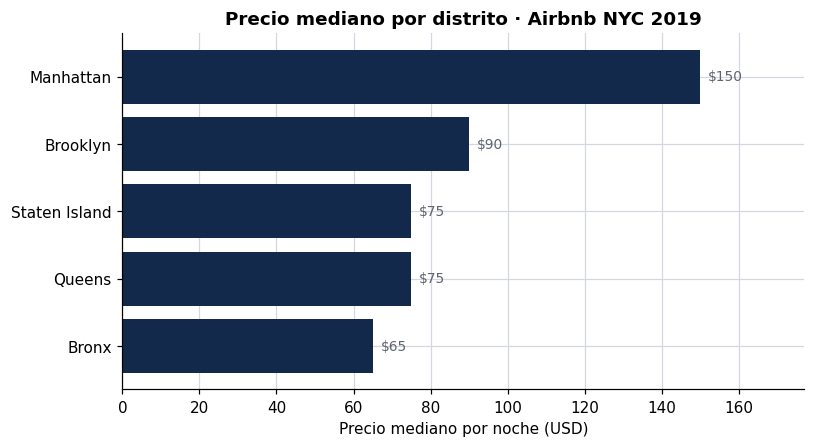

In [66]:
# 1) LOS DATOS: mediana por distrito, ordenada de menor a mayor
p = df.groupby("neighbourhood_group")["price"].median().sort_values()

# 2) EL LIENZO: fig es la figura completa; ax son los ejes donde se dibuja
fig, ax = plt.subplots()
ax.barh(p.index, p.values, color=AZUL)   # barh = barras HORIZONTALES

# 3) LAS CAPAS: cada línea le agrega una pieza al gráfico
ax.set_xlabel("Precio mediano por noche (USD)")            # el eje, CON unidades
ax.set_title("Precio mediano por distrito · Airbnb NYC 2019")

# el valor escrito al final de cada barra: quien lee no tiene que adivinarlo
for y, v in enumerate(p.values):
    ax.text(v + 2, y, f"${v:,.0f}", va="center", color=GRIS, fontsize=9)

ax.set_xlim(0, p.max() * 1.18)   # 18 % de aire a la derecha para que quepa el texto
plt.show()

> Barras **horizontales** con etiquetas de texto largo, y **ordenadas por valor**: eso es
> lo que hace que el gráfico responda solo. Y **mediana**, no media — ya sabemos por qué.

## 3.2 · `hist` — ¿cómo se reparten los precios?

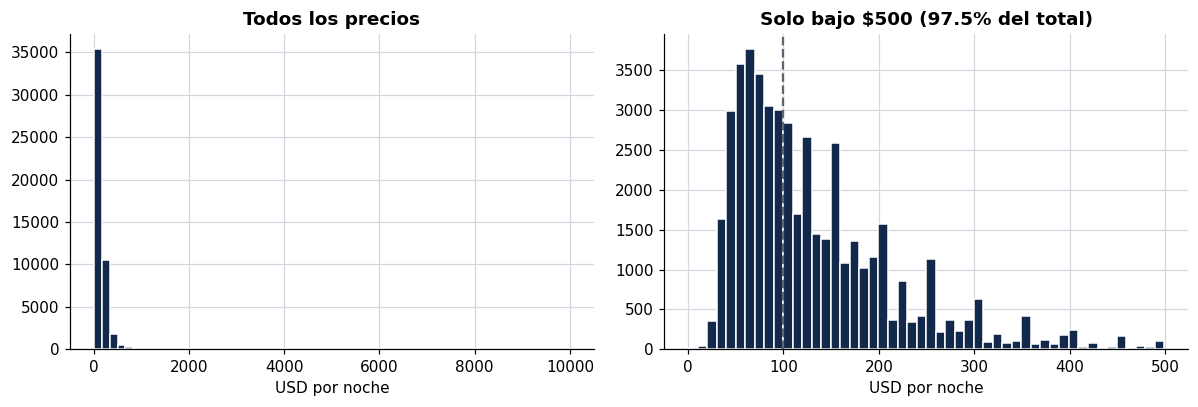

Pie de figura: se excluyen los de $500 o más (2.5%, n = 1,235).


In [67]:
# subplots(1, 2) = una fila con dos gráficos lado a lado → axes[0] y axes[1]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# IZQUIERDA: todos los precios. bins = en cuántas barras se parte el rango.
axes[0].hist(df["price"], bins=60, color=AZUL, edgecolor="white")
axes[0].set_title("Todos los precios")
axes[0].set_xlabel("USD por noche")

# DERECHA: el mismo dato, recortado bajo $500.
sub = df[df["price"] < 500]
axes[1].hist(sub["price"], bins=50, color=AZUL, edgecolor="white")
axes[1].axvline(sub["price"].median(), color=GRIS, ls="--")   # línea vertical en la mediana
axes[1].set_title(f"Solo bajo $500 ({len(sub)/len(df):.1%} del total)")
axes[1].set_xlabel("USD por noche")

plt.tight_layout()   # evita que los títulos y las etiquetas se pisen
plt.show()

# Lo que se recorta SE DECLARA. Esto es el pie de figura:
print(f"Pie de figura: se excluyen los de $500 o más "
      f"({(df['price'] >= 500).mean():.1%}, n = {(df['price'] >= 500).sum():,}).")

🔴 **El de la izquierda es inútil, y esa es la lección.** Unos pocos alojamientos de
\$10,000 estiran el eje hasta aplastar al 99 % restante. El de la derecha es el mismo dato,
recortado: asimétrico, con **cola larga a la derecha** — la forma típica de precios y rentas.

> **Recortar el eje es una decisión, y se declara** en el pie de figura.
> Recortar sin decirlo es maquillar.

## 3.3 · `scatter` — ¿los más caros reciben menos reseñas?

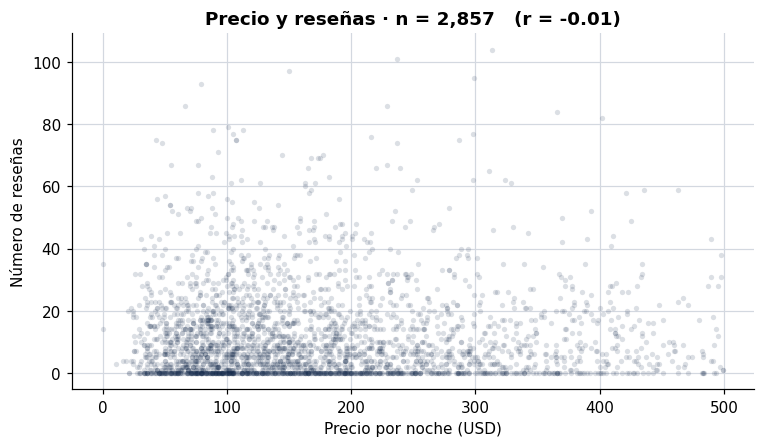

In [27]:
# Recortamos los dos ejes para poder ver la nube (y lo declaramos con la n en el título).
sub = df[(df["price"] < 500) & (df["number_of_reviews"] < 200)]

fig, ax = plt.subplots()
# un punto por alojamiento: x = precio, y = reseñas
# alpha = transparencia · s = tamaño del punto · lw = grosor del borde
ax.scatter(sub["price"], sub["number_of_reviews"], color=AZUL, alpha=.15, s=12, lw=0)
ax.set_xlabel("Precio por noche (USD)")
ax.set_ylabel("Número de reseñas")

# .corr() = correlación de Pearson, de -1 a 1. Cerca de 0 = no hay relación lineal.
r = sub["price"].corr(sub["number_of_reviews"])
ax.set_title(f"Precio y reseñas · n = {len(sub):,}   (r = {r:.2f})")
plt.show()

> **`alpha=.15` no es estético.** Con decenas de miles de puntos, sin transparencia el
> gráfico es una mancha negra. La transparencia convierte la densidad en información.

---

### 🟠 EN VIVO — matplotlib

**¿Qué tipo de habitación es más caro?** Haz el gráfico que responde esa pregunta
—elige tú cuál— con título y etiqueta de eje **con unidades**.

Text(0.5, 1.0, 'Precio mediano por tipo de habitación')

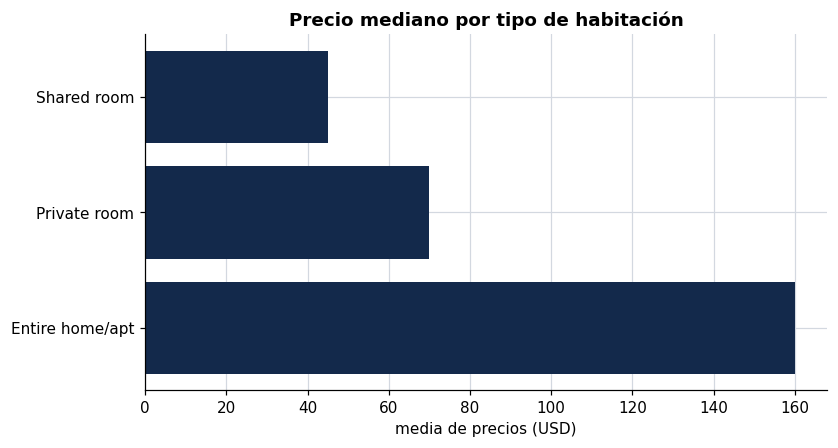

In [69]:
# TODO: 1) los datos: df.groupby("room_type")["price"].median()
data_grupo= df.groupby("room_type")["price"].median()
#       2) el gráfico: fig, ax = plt.subplots() y luego ax.barh(...)
fig, ax = plt.subplots()
ax.barh(data_grupo.index, data_grupo.values, color=AZUL)
#       3) las capas: ax.set_xlabel(...) con UNIDADES y ax.set_title(...)
ax.set_xlabel("media de precios (USD)")
ax.set_title("Precio mediano por tipo de habitación")
#

---
---
# Toda la clase, en una página

| | Para qué | |
|---|---|---|
| **Estructuras nativas** | JSON, texto, lógica a medida | todo lo que aún no es tabla |
| **NumPy** | cálculo numérico | un dtype, memoria contigua, vectorización |
| **pandas** | tablas con etiquetas | filtrar, agrupar, resumir |
| **matplotlib** | que otra persona entienda el hallazgo | sin que ustedes estén al lado |

### Las cuatro que hay que llevarse

1. **El tipo manda.** Ante un error, pregunta `type()`.
2. **Si escribiste un `for` sobre datos, hay una forma vectorizada.**
3. **Media ≠ mediana.** Cuando difieren mucho, «el promedio» engaña.
4. **Un `NaN` no es un cero.** Antes de rellenarlo, pregunta *por qué* falta.

---

## Ahora sí: al laboratorio 🧪

Cuaderno **`clase2_laboratorio_ESTUDIANTE.ipynb`**, en las salas asignadas.
Al cerrar, cada sala comparte:

1. **Un hallazgo** — una frase, con el número que la respalda
2. **El gráfico** que lo sostiene — ¿se entiende sin que ustedes hablen?
3. **Una advertencia** — algo que estos datos **NO** permiten concluir ← *la que más importa*
4. **Dónde usaron IA** — y qué hace ese código, o qué alternativa pensaron

---

**Problem set 1** — entrega miércoles 26 de agosto · **Discusión 1** abierta en el foro
**Próxima clase (lun 24):** vectores y matrices · tendencia central y dispersión · correlación